In [1]:
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt

# # Load AirPassengers dataset
# url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
# data = pd.read_csv(url, parse_dates=['Month'])
# data.columns = ['Month', 'Passengers']
# data['Month'] = pd.to_datetime(data['Month'])

# # Simulate decomposition: extract components using seasonal_decompose
# from statsmodels.tsa.seasonal import seasonal_decompose

# decompose_result = seasonal_decompose(data['Passengers'], model='additive', period=12)

# # Add components to DataFrame
# data['Trend'] = decompose_result.trend
# data['Seasonality'] = decompose_result.seasonal
# data['Residual'] = decompose_result.resid

# # Reconstruct to verify: Original = Trend + Seasonality + Residual
# data['Reconstructed'] = data['Trend'] + data['Seasonality'] + data['Residual']

# # Export to Excel
# excel_path = "airline_decomposition.xlsx"
# data.to_excel(excel_path, index=False)

# excel_path


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the dataset
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv'
df = pd.read_csv(url, parse_dates=['Month'])
df.columns = ['Month', 'Passengers']
df.set_index('Month', inplace=True)


In [3]:
df.head()

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [5]:
df.tail()

,Passengers
Month,
1960-08-01,606
1960-09-01,508
1960-10-01,461
1960-11-01,390
1960-12-01,432


In [7]:
# Trend using centered 12-month moving average
df['Trend'] = df['Passengers'].rolling(window=12, center=True).mean()

In [51]:
df.head(12)

,Passengers,Trend
Month,,
1949-01-01,112,NaN
1949-02-01,118,NaN
1949-03-01,132,NaN
1949-04-01,129,NaN
1949-05-01,121,NaN
1949-06-01,135,NaN
1949-07-01,148,126.666667
1949-08-01,148,126.916667
1949-09-01,136,127.583333


In [53]:
#Detrend the series
df['Detrended'] = df['Passengers'] - df['Trend']


In [55]:
df.head(20)

,Passengers,Trend,Detrended
Month,,,
1949-01-01,112,NaN,NaN
1949-02-01,118,NaN,NaN
1949-03-01,132,NaN,NaN
1949-04-01,129,NaN,NaN
1949-05-01,121,NaN,NaN
1949-06-01,135,NaN,NaN
1949-07-01,148,126.666667,21.333333
1949-08-01,148,126.916667,21.083333
1949-09-01,136,127.583333,8.416667


In [57]:
#Calculate seasonality

In [59]:
# Extract month number (1-12)
df['Month_Num'] = df.index.month

# Group by month and average the detrended values (ignoring NaNs)
monthly_avg = df.groupby('Month_Num')['Detrended'].mean()
# Map seasonal effect back to each row
df['Seasonality'] = df['Month_Num'].map(monthly_avg)


In [61]:
df

,Passengers,Trend,Detrended,Month_Num,Seasonality
Month,,,,,
1949-01-01,112,NaN,NaN,1,-23.704545
1949-02-01,118,NaN,NaN,2,-35.204545
1949-03-01,132,NaN,NaN,3,-1.583333
1949-04-01,129,NaN,NaN,4,-7.492424
1949-05-01,121,NaN,NaN,5,-4.174242
...,...,...,...,...,...
1960-08-01,606,NaN,NaN,8,63.106061
1960-09-01,508,NaN,NaN,9,16.856061
1960-10-01,461,NaN,NaN,10,-20.136364


In [63]:
#Calculate Noise
df['Residual'] = df['Passengers'] - df['Trend'] - df['Seasonality']


In [65]:
df.to_excel("Additive.xlsx",index=False)

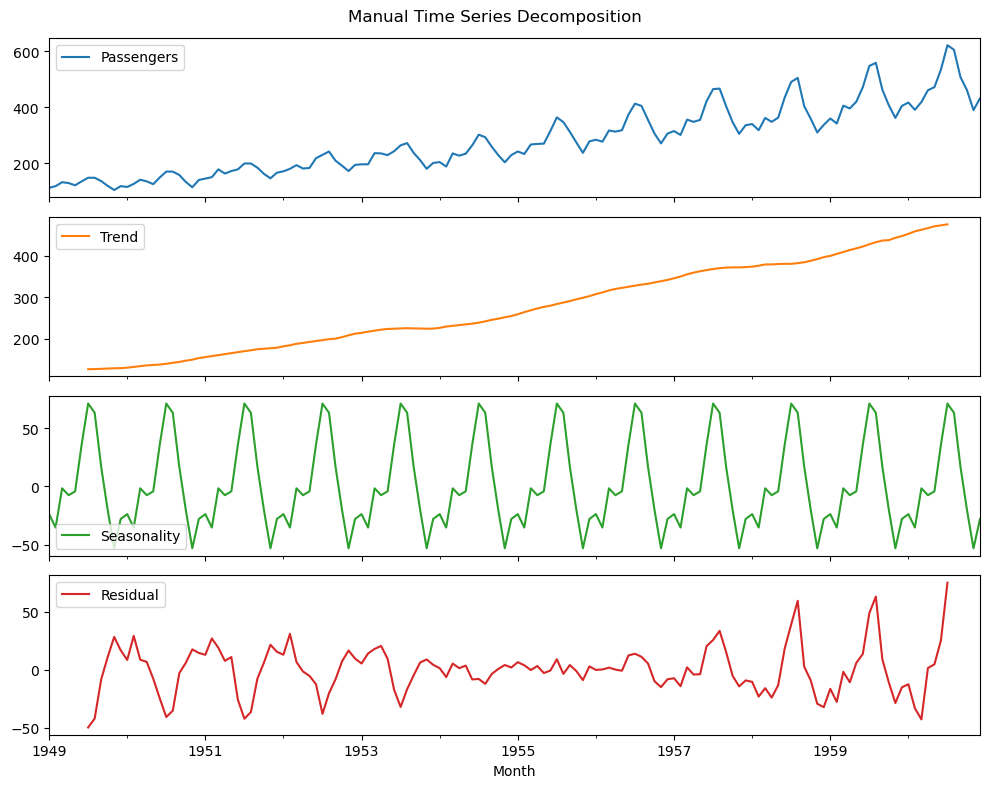

In [12]:
df[['Passengers', 'Trend', 'Seasonality', 'Residual']].plot(subplots=True, figsize=(10, 8), title="Manual Time Series Decomposition")
plt.tight_layout()
plt.show()


In [13]:
# 📁 Load dataset: Monthly Airline Passengers
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url, parse_dates=['Month'], index_col='Month')

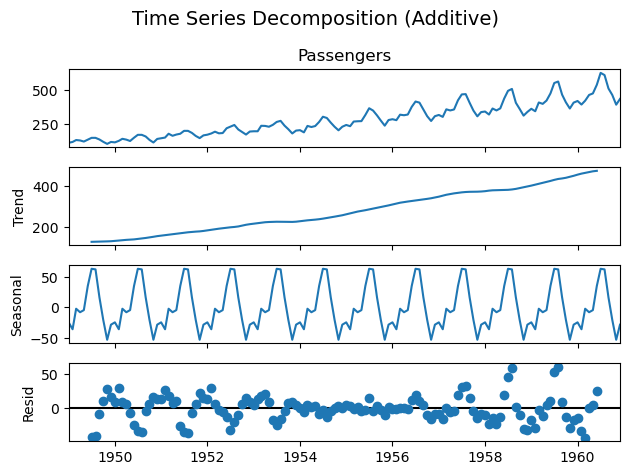

In [15]:
from statsmodels.tsa.seasonal import seasonal_decompose
# ⚙️ Decompose the time series (multiplicative)
result = seasonal_decompose(df['Passengers'], model='additive')

# 📉 Plot decomposition
result.plot()
plt.suptitle('Time Series Decomposition (Additive)', fontsize=14)
plt.tight_layout()
plt.show()


# Multiplicative

In [33]:
# Load the dataset
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv'
df = pd.read_csv(url, parse_dates=['Month'])
df.columns = ['Month', 'Passengers']
df.set_index('Month', inplace=True)

In [35]:
df["Trend"] = df["Passengers"].rolling(window=12, center=True).mean()


In [37]:
# In multiplicative decomposition, we divide the original series by the trend:

df["Detrended"] = df["Passengers"] / df["Trend"]


In [39]:
# Seasonality
df["Month_Num"] = df.index.month
monthly_avg = df.groupby("Month_Num")["Detrended"].mean()
df["Seasonality"] = df["Month_Num"].map(monthly_avg)

In [41]:
#Now didvide the season effect from the dtrented series
df["Residual"] = df["Passengers"] / (df["Trend"] * df["Seasonality"])


In [43]:
df.to_excel("Multiplicative.xlsx",index=False)

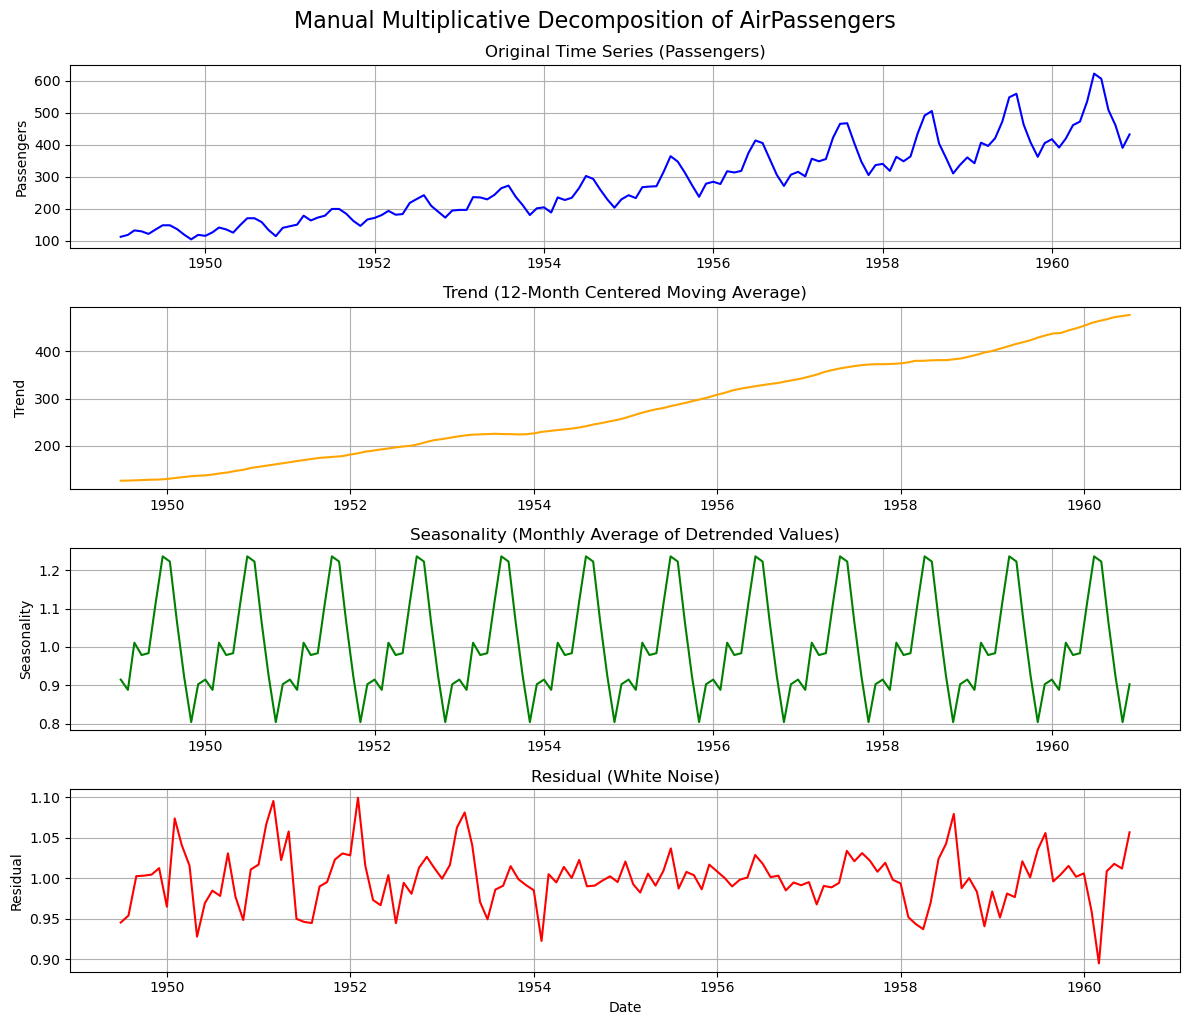

In [29]:
import matplotlib.pyplot as plt

# Ensure plots are wide enough and nicely spaced
plt.figure(figsize=(12, 10))

# Plot Original Series
plt.subplot(4, 1, 1)
plt.plot(df.index, df["Passengers"], label="Original", color="blue")
plt.title("Original Time Series (Passengers)")
plt.ylabel("Passengers")
plt.grid(True)

# Plot Trend
plt.subplot(4, 1, 2)
plt.plot(df.index, df["Trend"], label="Trend", color="orange")
plt.title("Trend (12-Month Centered Moving Average)")
plt.ylabel("Trend")
plt.grid(True)

# Plot Seasonality
plt.subplot(4, 1, 3)
plt.plot(df.index, df["Seasonality"], label="Seasonality", color="green")
plt.title("Seasonality (Monthly Average of Detrended Values)")
plt.ylabel("Seasonality")
plt.grid(True)

# Plot Residuals
plt.subplot(4, 1, 4)
plt.plot(df.index, df["Residual"], label="Residual", color="red")
plt.title("Residual (White Noise)")
plt.ylabel("Residual")
plt.xlabel("Date")
plt.grid(True)

plt.tight_layout()
plt.suptitle("Manual Multiplicative Decomposition of AirPassengers", fontsize=16, y=1.02)
plt.show()


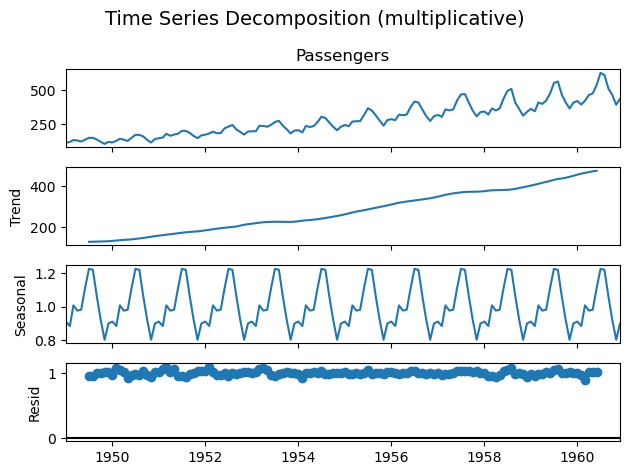

In [31]:
from statsmodels.tsa.seasonal import seasonal_decompose
# ⚙️ Decompose the time series (multiplicative)
result = seasonal_decompose(df['Passengers'], model='multiplicative')

# 📉 Plot decomposition
result.plot()
plt.suptitle('Time Series Decomposition (multiplicative)', fontsize=14)
plt.tight_layout()
plt.show()


C:\Users\rajbo\AppData\Local\Temp\ipykernel_72300\2116508413.py:15: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  'Month': pd.date_range(start='2010-01-01', periods=n_months, freq='M'),


<Axes: title={'center': 'Synthetic Additive Time Series'}, xlabel='Month'>

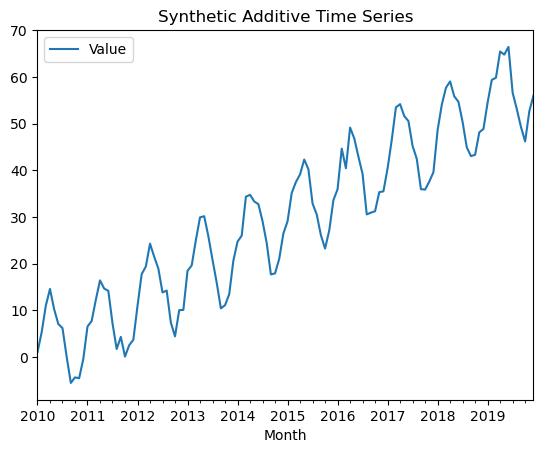

In [67]:
# Additive example dataset
import numpy as np
import pandas as pd

np.random.seed(42)
n_months = 120
time = np.arange(n_months)
trend = time * 0.5
seasonality = 10 * np.sin(2 * np.pi * time / 12)
noise = np.random.normal(0, 2, n_months)

additive_series = trend + seasonality + noise

df = pd.DataFrame({
    'Month': pd.date_range(start='2010-01-01', periods=n_months, freq='M'),
    'Value': additive_series
})
df.set_index('Month', inplace=True)
df.plot(title='Synthetic Additive Time Series')


In [71]:
df

,Value
Month,
2010-01-31,0.993428
2010-02-28,5.223471
2010-03-31,10.955631
2010-04-30,14.546060
2010-05-31,10.191947
...,...
2019-08-31,53.103095
2019-09-30,49.270322
2019-10-31,46.162644


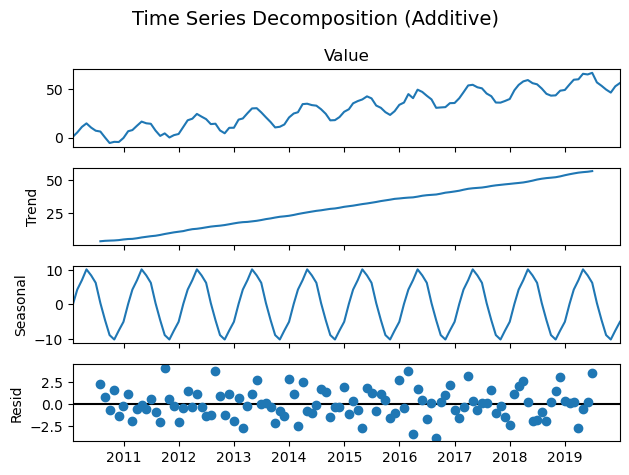

In [73]:
from statsmodels.tsa.seasonal import seasonal_decompose
# ⚙️ Decompose the time series (additive)
result = seasonal_decompose(df['Value'], model='additive')

result.plot()
plt.suptitle('Time Series Decomposition (Additive)', fontsize=14)
plt.tight_layout()
plt.show()
